# Random Forest

In [86]:
# imports

from pathlib import Path # file paths

import numpy as np # numerical operations
import pandas as pd #csv handling

import matplotlib.pyplot as plt # plotting

from sklearn.ensemble import RandomForestClassifier # machine learning model
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split, GridSearchCV # model evaluation
# metrics
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report, 
    precision_score,
    recall_score,
    RocCurveDisplay
)

from sklearn.model_selection import RandomizedSearchCV # tuning 
from scipy.stats import randint

### 1. Settings

In [87]:
FEATURES_PATH = Path("outputs") / "eeg_features_data.csv"
OUTPUT_DIR = Path("outputs") # directory for outputs
OUTPUT_DIR.mkdir(parents=True, exist_ok=True) # create output directory if it doesn't exist
FIGURES_DIR = OUTPUT_DIR / "figures"
TABS_DIR = OUTPUT_DIR / "tabs"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABS_DIR.mkdir(parents=True, exist_ok=True)

features_df = pd.read_csv(FEATURES_PATH)

print("Shape:", features_df.shape)
display(features_df.head())

print("Class distribution:")
display(features_df["Class"].value_counts())

Shape: (121, 124)


,ID,Class,n_samples,duration_sec,Fp1_delta_power,Fp1_theta_power,Fp1_alpha_power,Fp1_beta_power,Fp1_theta_beta_ratio,Fp2_delta_power,...,temporal_delta_power_mean,temporal_theta_power_mean,temporal_alpha_power_mean,temporal_beta_power_mean,temporal_theta_beta_ratio,occipital_delta_power_mean,occipital_theta_power_mean,occipital_alpha_power_mean,occipital_beta_power_mean,occipital_theta_beta_ratio
0,v10p,ADHD,14304,111.750000,20764.347948,4433.165153,1163.116779,1220.075523,3.633517,19985.184042,...,5839.205234,1832.689764,2206.839430,2033.163635,0.901398,5313.211114,2515.280960,1239.193542,2047.478172,1.228478
1,v12p,ADHD,17604,137.531250,35697.951547,7797.099598,1427.690126,1028.902332,7.578076,29986.175718,...,23000.755768,3191.807975,1139.959981,908.476562,3.513363,9076.262423,3731.706544,1414.186873,2011.651626,1.855046
2,v14p,ADHD,17562,137.203125,124322.835760,34554.128417,4828.326846,5765.890863,5.992852,198052.819591,...,32551.843934,5516.419259,2188.738526,2493.216978,2.212571,21449.856904,6070.162746,2775.817586,3659.736876,1.658634
3,v15p,ADHD,43252,337.906250,25609.106999,7425.362020,2163.548768,1443.360033,5.144497,21041.122924,...,13208.390881,3255.140409,2278.065705,1660.059682,1.960857,14728.933087,4269.300202,1999.343488,1661.070205,2.570211
4,v173,ADHD,24241,189.382812,6962.611895,3144.051753,1982.601543,6955.012349,0.452056,7648.534786,...,2837.889255,1387.619299,730.351150,2373.689547,0.584583,5284.728897,2475.850442,1332.758218,4059.060983,0.609956


Class distribution:


Class
ADHD       61
Control    60
Name: count, dtype: int64

In [88]:
# Pretty names for plots

FEATURE_LABELS = {
    "frontal_theta_power_mean": "Frontal " r"${\theta}$ power",
    "frontal_beta_power_mean": "Frontal " r"${\beta}$ power",
    "frontal_theta_beta_ratio": "Frontal " r"${\theta}/{\beta}$ ratio",
    "occipital_beta_power_mean": "Occipital " r"${\beta}$ power",
    "temporal_theta_beta_ratio": "Temporal " r"${\theta}/{\beta}$ ratio",
    "occipital_theta_beta_ratio": "Occipital " r"${\theta}/{\beta}$ ratio",
    "parietal_theta_beta_ratio": "Parietal " r"${\theta}/{\beta}$ ratio",
    "central_theta_beta_ratio": "Central " r"${\theta}/{\beta}$ ratio",
    "T7_theta_beta_ratio": "T7 " r"${\theta}/{\beta}$ ratio",
    "P7_theta_beta_ratio": "P7 " r"${\theta}/{\beta}$ ratio",
    "Pz_theta_beta_ratio": "Pz " r"${\theta}/{\beta}$ ratio",
    "O1_theta_beta_ratio": "O1 " r"${\theta}/{\beta}$ ratio",
    "F4_theta_beta_ratio": "F4 " r"${\theta}/{\beta}$ ratio",
    "temporal_theta_power_mean": "Temporal " r"${\theta}$ power",
    "temporal_beta_power_mean": "Temporal " r"${\beta}$ power",
    "occipital_theta_power_mean": "Occipital " r"${\theta}$ power",
    "parietal_theta_power_mean": "Parietal " r"${\theta}$ power",
    "parietal_beta_power_mean": "Parietal " r"${\beta}$ power",
    "parietal_theta_beta_ratio": "Parietal " r"${\theta}/{\beta}$ ratio",
    "parietal_theta_power_mean": "Parietal " r"${\theta}$ power",
    "parietal_beta_power_mean": "Parietal " r"${\beta}$ power",
    "parietal_delta_power_mean": "Parietal " r"${\delta}$ power",
    "Pz_theta_power_mean": "Pz " r"${\theta}$ power",
    "Pz_beta_power_mean": "Pz " r"${\beta}$ power",
    "Pz_delta_power_mean": "Pz " r"${\delta}$ power",
    "Pz_delta_power":"Pz " r"${\delta}$ power",
    "F4_theta_power": "F4 " r"${\theta}$ power",
    "F4_beta_power": "F4 " r"${\beta}$ power",
    "Fp1_theta_beta_ratio": "Fp1 " r"${\theta}/{\beta}$ ratio",
    "F3_theta_beta_ratio": "F3 " r"${\theta}/{\beta}$ ratio",
    "C3_theta_beta_ratio": "C3 " r"${\theta}/{\beta}$ ratio",
    "P3_theta_beta_ratio": "P3 " r"${\theta}/{\beta}$ ratio",
    "T8_theta_beta_ratio": "T8 " r"${\theta}/{\beta}$ ratio",
    "F8_theta_beta_ratio": "F8 " r"${\theta}/{\beta}$ ratio",
    "O2_theta_beta_ratio": "O2 " r"${\theta}/{\beta}$ ratio",
    "C4_theta_beta_ratio": "C4 " r"${\theta}/{\beta}$ ratio",
    "F7_theta_beta_ratio": "F7 " r"${\theta}/{\beta}$ ratio",
    "F7_theta_power": "F7 " r"${\theta}$ power",
    "F7_beta_power": "F7 " r"${\beta}$ power",
    "F3_theta_power": "F3 " r"${\theta}$ power",
    "F3_beta_power": "F3 " r"${\beta}$ power",
    "C3_theta_power": "C3 " r"${\theta}$ power",
    "C3_beta_power": "C3 " r"${\beta}$ power",
    "P3_theta_power": "P3 " r"${\theta}$ power",
    "P3_beta_power": "P3 " r"${\beta}$ power",
    "T8_theta_power": "T8 " r"${\theta}$ power",
    "T8_beta_power": "T8 " r"${\beta}$ power",
    "F8_theta_power": "F8 " r"${\theta}$ power",
    "F8_beta_power": "F8 " r"${\beta}$ power",
    "O2_theta_power": "O2 " r"${\theta}$ power",
    "O2_beta_power": "O2 " r"${\beta}$ power",
    "C4_theta_power": "C4 " r"${\theta}$ power",
    "C4_beta_power": "C4 " r"${\beta}$ power",
    "Fp1_theta_power": "Fp1 " r"${\theta}$ power",
    "Fp1_beta_power": "Fp1 " r"${\beta}$ power",
    "Pz_theta_power": "Pz " r"${\theta}$ power",
    "Pz_beta_power": "Pz " r"${\beta}$ power",
    "F4_theta_beta_ratio": "F4 " r"${\theta}/{\beta}$ ratio",
    "F7_theta_beta_ratio": "F7 " r"${\theta}/{\beta}$ ratio",
    "F3_theta_beta_ratio": "F3 " r"${\theta}/{\beta}$ ratio",
    "C3_theta_beta_ratio": "C3 " r"${\theta}/{\beta}$ ratio",
    "P3_theta_beta_ratio": "P3 " r"${\theta}/{\beta}$ ratio",
    "T8_theta_beta_ratio": "T8 " r"${\theta}/{\beta}$ ratio",
    "F8_theta_beta_ratio": "F8 " r"${\theta}/{\beta}$ ratio",
    "O2_theta_beta_ratio": "O2 " r"${\theta}/{\beta}$ ratio",
    "C4_theta_beta_ratio": "C4 " r"${\theta}/{\beta}$ ratio",
    "Fp1_theta_beta_ratio": "Fp1 " r"${\theta}/{\beta}$ ratio",
    "Pz_theta_beta_ratio": "Pz " r"${\theta}/{\beta}$ ratio",
    "duration_sec": "Recording duration (s)",
    "n_samples": "Number of samples",
    "id": "ID",
    "class": "Class",
    "P7_theta_beta_ratio": "P7 " r"${\theta}/{\beta}$ ratio",
    "P7_theta_power": "P7 " r"${\theta}$ power",
    "P7_beta_power": "P7 " r"${\beta}$ power",
    "P7_delta_power": "P7 " r"${\delta}$ power",
    "occipital_delta_power_mean": "Occipital " r"${\delta}$ power",
    "central_theta_power_mean": "Central " r"${\theta}$ power",
    "central_beta_power_mean": "Central " r"${\beta}$ power",
    "central_alpha_power_mean": "Central " r"${\alpha}$ power",
    "parietal_alpha_power_mean": "Parietal " r"${\alpha}$ power",
    "frontal_alpha_power_mean": "Frontal " r"${\alpha}$ power",
    "temporal_delta_power_mean": "Temporal " r"${\delta}$ power",
    "central_delta_power_mean": "Central " r"${\delta}$ power",
    "temporal_alpha_power_mean": "Temporal " r"${\alpha}$ power",

}


In [ ]:
# useful functions

def pretty_feature_name(feature):
    """
    Return a readable name for a feature.
    If the feature is not in FEATURE_LABELS, return the original name.
    """
    return FEATURE_LABELS.get(feature, feature) 

def save_figure(filename, dpi=300):
    """
    Save the current matplotlib figure inside outputs/figures.
    """
    output_path = FIGURES_DIR / filename
    plt.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print("Figure saved to:", output_path)

def save_table(df, filename, index=False):
    """
    Save a pandas DataFrame inside outputs/tabs.
    """
    output_path = TABS_DIR / filename
    df.to_csv(output_path, index=index)
    print("Table saved to:", output_path)

def randomized_then_local_grid_search(
    X_train,
    y_train,
    model_name,
    n_iter=80,
    random_state=42
):
    """
    Perform two-step hyperparameter tuning:
    1. RandomizedSearchCV;
    2. GridSearchCV around the best randomized-search parameters.
    """

    random_param_dist = {
        "n_estimators": randint(200, 1500),
        "max_depth": [None, 3, 5, 7, 10, 15, 20, 30],
        "min_samples_leaf": randint(1, 10),
        "min_samples_split": randint(2, 15),
        "max_features": ["sqrt", "log2", None]
    }

    base_rf_model = RandomForestClassifier(
        random_state=random_state,
        class_weight="balanced"
    )

    random_search = RandomizedSearchCV(
        estimator=base_rf_model,
        param_distributions=random_param_dist,
        n_iter=n_iter,
        scoring="balanced_accuracy",
        cv=cv,
        n_jobs=-1,
        random_state=random_state,
        return_train_score=True
    )

    random_search.fit(X_train, y_train)

    print(f"\n{model_name}")
    print("Best parameters from RandomizedSearchCV:")
    print(random_search.best_params_)
    print("Best randomized-search CV balanced accuracy:")
    print(random_search.best_score_)

    random_search_results_df = pd.DataFrame(
        random_search.cv_results_
    ).sort_values("rank_test_score")

    save_table(
        random_search_results_df,
        f"2a_rf_{model_name}_randomized_search_results.csv"
    )

    random_best_params_df = pd.DataFrame([random_search.best_params_])
    random_best_params_df["best_randomized_cv_balanced_accuracy"] = random_search.best_score_

    save_table(
        random_best_params_df,
        f"2a_rf_{model_name}_randomized_search_best_params.csv"
    )

    best_random_params = random_search.best_params_

    best_n_estimators = best_random_params["n_estimators"]
    best_max_depth = best_random_params["max_depth"]
    best_min_samples_leaf = best_random_params["min_samples_leaf"]
    best_min_samples_split = best_random_params["min_samples_split"]
    best_max_features = best_random_params["max_features"]

    def make_int_grid(center, step, min_value):
        values = [
            max(min_value, center - step),
            center,
            center + step
        ]
        return sorted(list(set(values)))

    if best_max_depth is None:
        local_max_depth_values = [None, 5, 10, 15, 20, 30]
    else:
        local_max_depth_values = sorted(
            list(set([
                None,
                max(1, best_max_depth - 5),
                best_max_depth,
                best_max_depth + 5
            ])),
            key=lambda x: 999 if x is None else x
        )

    local_param_grid = {
        "n_estimators": make_int_grid(
            center=best_n_estimators,
            step=200,
            min_value=100
        ),
        "max_depth": local_max_depth_values,
        "min_samples_leaf": make_int_grid(
            center=best_min_samples_leaf,
            step=1,
            min_value=1
        ),
        "min_samples_split": make_int_grid(
            center=best_min_samples_split,
            step=2,
            min_value=2
        ),
        "max_features": list(dict.fromkeys([
            best_max_features,
            "sqrt",
            "log2",
            None
        ]))
    }

    print("\nLocal parameter grid:")
    display(local_param_grid)

    local_grid_search = GridSearchCV(
        estimator=base_rf_model,
        param_grid=local_param_grid,
        scoring="balanced_accuracy",
        cv=cv,
        n_jobs=-1,
        return_train_score=True
    )

    local_grid_search.fit(X_train, y_train)

    print("Best parameters after local GridSearchCV:")
    print(local_grid_search.best_params_)
    print("Best local grid-search CV balanced accuracy:")
    print(local_grid_search.best_score_)

    local_grid_results_df = pd.DataFrame(
        local_grid_search.cv_results_
    ).sort_values("rank_test_score")

    save_table(
        local_grid_results_df,
        f"2a_rf_{model_name}_local_grid_search_results.csv"
    )

    local_grid_best_params_df = pd.DataFrame([local_grid_search.best_params_])
    local_grid_best_params_df["best_local_grid_cv_balanced_accuracy"] = local_grid_search.best_score_

    save_table(
        local_grid_best_params_df,
        f"2a_rf_{model_name}_local_grid_search_best_params.csv"
    )

    display(local_grid_best_params_df)

    return local_grid_search

def evaluate_final_model_on_test_set(
    fitted_model,
    X_train,
    y_train,
    X_test,
    y_test,
    feature_set_name,
    n_features,
    output_prefix,
    extra_info=None
):
    """
    Train the selected model on the training set
    and evaluate it once on the test set.
    """

    fitted_model.fit(X_train, y_train)

    y_test_pred = fitted_model.predict(X_test)
    y_test_proba = fitted_model.predict_proba(X_test)[:, 1]

    final_results = {
        "feature_set": feature_set_name,
        "n_features": n_features,
        "accuracy": accuracy_score(y_test, y_test_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred),
        "precision": precision_score(y_test, y_test_pred),
        "recall": recall_score(y_test, y_test_pred),
        "f1": f1_score(y_test, y_test_pred),
        "roc_auc": roc_auc_score(y_test, y_test_proba)
    }

    if extra_info is not None:
        final_results.update(extra_info)

    final_results_df = pd.DataFrame([final_results])

    save_table(
        final_results_df,
        f"{output_prefix}_test_metrics.csv"
    )

    display(final_results_df)

    # ROC curve
    plt.figure(figsize=(6, 6))

    RocCurveDisplay.from_predictions(
        y_test,
        y_test_proba,
        name=feature_set_name
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="black",
        linewidth=1,
        label="Chance"
    )

    plt.title(f"ROC curve on final test set\n{feature_set_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.grid(
        linestyle="--",
        alpha=0.4
    )

    plt.tight_layout()

    save_figure(
        f"{output_prefix}_roc_curve.png"
    )

    plt.show()

    # Confusion matrix
    cm = confusion_matrix(
        y_test,
        y_test_pred,
        labels=[0, 1]
    )

    cm_df = pd.DataFrame(
        cm,
        index=["True Control", "True ADHD"],
        columns=["Predicted Control", "Predicted ADHD"]
    )

    save_table(
        cm_df,
        f"{output_prefix}_confusion_matrix.csv",
        index=True
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Control", "ADHD"]
    )

    disp.plot(cmap="Greens")

    plt.title(f"Final test confusion matrix\n{feature_set_name}")

    plt.tight_layout()

    save_figure(
        f"{output_prefix}_confusion_matrix.png"
    )

    plt.show()

    display(cm_df)

    # Classification report
    report_dict = classification_report(
        y_test,
        y_test_pred,
        target_names=["Control", "ADHD"],
        output_dict=True
    )

    report_df = pd.DataFrame(report_dict).T

    save_table(
        report_df,
        f"{output_prefix}_classification_report.csv",
        index=True
    )

    display(report_df)

    return final_results_df, fitted_model, y_test_pred, y_test_proba

def evaluate_feature_set(feature_set_name, feature_cols):
    """
    Evaluate a Random Forest classifier using cross-validation
    only on the training/validation set.
    """

    X_train = train_df[feature_cols]

    scoring = [
        "accuracy",
        "balanced_accuracy",
        "f1",
        "roc_auc",
        "precision",
        "recall"
    ]

    cv_results = cross_validate(
        rf_model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    result = {
        "feature_set": feature_set_name,
        "n_features": len(feature_cols),

        "accuracy_mean": cv_results["test_accuracy"].mean(),
        "accuracy_std": cv_results["test_accuracy"].std(),

        "balanced_accuracy_mean": cv_results["test_balanced_accuracy"].mean(),
        "balanced_accuracy_std": cv_results["test_balanced_accuracy"].std(),

        "f1_mean": cv_results["test_f1"].mean(),
        "f1_std": cv_results["test_f1"].std(),

        "roc_auc_mean": cv_results["test_roc_auc"].mean(),
        "roc_auc_std": cv_results["test_roc_auc"].std(),

        "precision_mean": cv_results["test_precision"].mean(),
        "precision_std": cv_results["test_precision"].std(),

        "recall_mean": cv_results["test_recall"].mean(),
        "recall_std": cv_results["test_recall"].std()
    }

    return result

def select_uncorrelated_features_by_importance(
    ranked_features,
    data,
    corr_threshold=0.75,
    method="spearman"
):
    """
    Select features using correlation.

    Features are considered in order of importance.
    A feature is retained only if its absolute correlation with all already
    selected features is below the chosen threshold.
    """

    selected_features = []
    removed_features = []

    corr_matrix = data[ranked_features].corr(method=method).abs()

    for feature in ranked_features:

        if len(selected_features) == 0:
            selected_features.append(feature)

        else:
            max_corr_with_selected = corr_matrix.loc[
                feature,
                selected_features
            ].max()

            if max_corr_with_selected < corr_threshold:
                selected_features.append(feature)

            else:
                removed_features.append({
                    "removed_feature": feature,
                    "max_correlation_with_selected": max_corr_with_selected,
                    "most_correlated_selected_feature": corr_matrix.loc[
                        feature,
                        selected_features
                    ].idxmax()
                })

    removed_features_df = pd.DataFrame(removed_features)

    return selected_features, removed_features_df

### 2. Dataset preprocessing

### 2a. Train/test split

Before training the machine learning model, the dataset is divided into two separate parts: a training/validation set and an independent test set.

The training/validation set was used to compare different feature sets and to perform cross-validation. The independent test set was kept untouched during model selection and was used only once at the end for the final evaluation.

This separation is made to avoid data leakage.

In this analysis, 80% of the subjects were assigned to the training/validation set and 20% to the final test set. In the split the proportion of ADHD and Control subjects was preserved in both subsets.

### 2b. Cross Validation

Model comparison was performed using stratified 5-fold cross-validation on the training/validation set only.

In 5-fold cross-validation, the training/validation set is divided into five folds. At each iteration, the model is trained on four folds and validated on the remaining fold. This process is repeated five times, so that each fold is used once as validation data.

Cross-validation was used to compare the three feature sets:

1. all EEG features;
2. channel-level features only;
3. regional mean features only.

The independent test set was not used during cross-validation. It was kept aside and used only after selecting the best-performing feature set.




In [90]:
# train/test split

train_df, test_df = train_test_split(
    features_df,
    test_size=0.20,
    stratify=features_df["Class"],
    random_state=42
)

print("Train/validation shape:", train_df.shape)
print("Final test shape:", test_df.shape)

print("\nTrain/validation class distribution:")
display(train_df["Class"].value_counts())

print("\nFinal test class distribution:")
display(test_df["Class"].value_counts())

Train/validation shape: (96, 124)
Final test shape: (25, 124)

Train/validation class distribution:


Class
Control    48
ADHD       48
Name: count, dtype: int64


Final test class distribution:


Class
ADHD       13
Control    12
Name: count, dtype: int64

In [91]:
# define target variable

y_train = train_df["Class"].map({
    "Control": 0,
    "ADHD": 1
})

y_test = test_df["Class"].map({
    "Control": 0,
    "ADHD": 1
})

print("Train labels:")
display(y_train.value_counts())

print("Test labels:")
display(y_test.value_counts())

Train labels:


Class
0    48
1    48
Name: count, dtype: int64

Test labels:


Class
1    13
0    12
Name: count, dtype: int64

In [92]:
# features columns

metadata_cols = [
    "ID",
    "Class",
    "n_samples",
    "duration_sec"
]

all_feature_cols = [
    c for c in features_df.columns
    if c not in metadata_cols
]

all_feature_cols = [
    c for c in all_feature_cols
    if pd.api.types.is_numeric_dtype(features_df[c])
]

print("All EEG features:", len(all_feature_cols))

All EEG features: 120


In [93]:
# separate channel-level features from global features 

channel_feature_cols = [
    c for c in all_feature_cols
    if not (
        c.startswith("frontal_")
        or c.startswith("central_")
        or c.startswith("temporal_")
        or c.startswith("parietal_")
        or c.startswith("occipital_")
    )
]

print("Channel-level features:", len(channel_feature_cols))
print(channel_feature_cols[:10])

Channel-level features: 95
['Fp1_delta_power', 'Fp1_theta_power', 'Fp1_alpha_power', 'Fp1_beta_power', 'Fp1_theta_beta_ratio', 'Fp2_delta_power', 'Fp2_theta_power', 'Fp2_alpha_power', 'Fp2_beta_power', 'Fp2_theta_beta_ratio']


In [94]:
# separate regional mean features

regional_feature_cols = [
    c for c in all_feature_cols
    if (
        c.startswith("frontal_")
        or c.startswith("central_")
        or c.startswith("temporal_")
        or c.startswith("parietal_")
        or c.startswith("occipital_")
    )
]

print("Regional mean features:", len(regional_feature_cols))
print(regional_feature_cols)

Regional mean features: 25
['frontal_delta_power_mean', 'frontal_theta_power_mean', 'frontal_alpha_power_mean', 'frontal_beta_power_mean', 'frontal_theta_beta_ratio', 'central_delta_power_mean', 'central_theta_power_mean', 'central_alpha_power_mean', 'central_beta_power_mean', 'central_theta_beta_ratio', 'parietal_delta_power_mean', 'parietal_theta_power_mean', 'parietal_alpha_power_mean', 'parietal_beta_power_mean', 'parietal_theta_beta_ratio', 'temporal_delta_power_mean', 'temporal_theta_power_mean', 'temporal_alpha_power_mean', 'temporal_beta_power_mean', 'temporal_theta_beta_ratio', 'occipital_delta_power_mean', 'occipital_theta_power_mean', 'occipital_alpha_power_mean', 'occipital_beta_power_mean', 'occipital_theta_beta_ratio']


### 3. Random Forest

After exploring the EEG features statistically in *1b_features_exploration*, a Random Forest classifier was used to evaluate whether the extracted features can distinguish ADHD subjects from Control subjects and to classify the importance fo the features.

Three different feature sets were compared:

1. all EEG features;
2. channel-level features only;
3. regional mean features only.

This comparison allows us to investigate whether classification performance is driven mainly by detailed electrode-level information or by broader regional EEG patterns.

### 4. Classification metrics
Several metrics were used to evaluate the Random Forest classifier.

### 4a. Accuracy and balanced accuracy

Accuracy measures the proportion of correctly classified subjects:

$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

where $TP$ are true positives, $TN$ are true negatives, $FP$ are false positives, and $FN$ are false negatives.

However, accuracy can be misleading when the classes are imbalanced. For this reason, balanced accuracy was also used.

Balanced accuracy is the average of sensitivity and specificity:

$$
Balanced\ Accuracy = \frac{Sensitivity + Specificity}{2}
$$

where sensitivity measures the proportion of correctly identified ADHD subjects, and specificity measures the proportion of correctly identified Control subjects.

In this project thw two groups are actually balanced, so the two metrics shouldn't differ.

### 4b. Precision, recall and F1-score

Precision and recall describe different aspects of classification performance.

Precision measures how many subjects predicted as ADHD are actually ADHD:

$$
Precision = \frac{TP}{TP + FP}
$$

A high precision means that when the model predicts ADHD, it is often correct.

Recall, also called sensitivity, measures how many true ADHD subjects are correctly detected:

$$
Recall = \frac{TP}{TP + FN}
$$

A high recall means that the model correctly identifies most ADHD subjects.

The F1-score combines precision and recall into a single metric:

$$
F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
$$

### 4c. ROC-AUC

ROC-AUC evaluates how well the classifier separates the two classes across different decision thresholds.

The ROC curve plots the true positive rate against the false positive rate for different threshold values. The area under this curve is called ROC-AUC.

A ROC-AUC value of:

$$
0.5
$$

indicates performance similar to random guessing, while a value close to:

$$
1.0
$$

indicates excellent separation between the two classes.

### 4d. Confusion matrix

The confusion matrix provides a direct view of the model predictions.
This matrix makes it possible to see whether the model makes more errors in one class than the other.

In [95]:
# define model
rf_model = RandomForestClassifier(
    n_estimators=500, # number of trees in the forest
    max_depth=None, # allow trees to grow until all leaves are pure or until they contain less than min_samples_leaf samples
    min_samples_leaf=2, # minimum number of samples required to be at a leaf node
    random_state=42,# reproducibility
    class_weight="balanced" # handle class imbalance using weights proportional to class frequencies 
)

# cross-validation
cv = StratifiedKFold(
    n_splits=5, # number of folds
    shuffle=True, # shuffle data before splitting 
    random_state=42 # reproducibility
)

In [96]:
rf_results = []

rf_results.append(
    evaluate_feature_set(
        "All EEG features",
        all_feature_cols
    )
)

rf_results.append(
    evaluate_feature_set(
        "Channel-level features",
        channel_feature_cols
    )
)

rf_results.append(
    evaluate_feature_set(
        "Regional mean features",
        regional_feature_cols
    )
)

rf_results_df = pd.DataFrame(rf_results)

save_table(
    rf_results_df,
    "2a_rf_feature_set_comparison.csv"
)

display(rf_results_df)

Table saved to: outputs\tabs\2a_rf_feature_set_comparison.csv


,feature_set,n_features,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std
0,All EEG features,120,0.675789,0.073353,0.676667,0.075310,0.699043,0.062402,0.673778,0.094149,0.659744,0.080831,0.751111,0.082132
1,Channel-level features,95,0.613684,0.058191,0.610000,0.062991,0.646053,0.041228,0.681111,0.058119,0.603645,0.055569,0.706667,0.085664
2,Regional mean features,25,0.675789,0.119352,0.677778,0.112930,0.699952,0.093135,0.728889,0.091786,0.670000,0.113725,0.748889,0.105081


Figure saved to: outputs\figures\2a_rf_feature_set_comparison.png


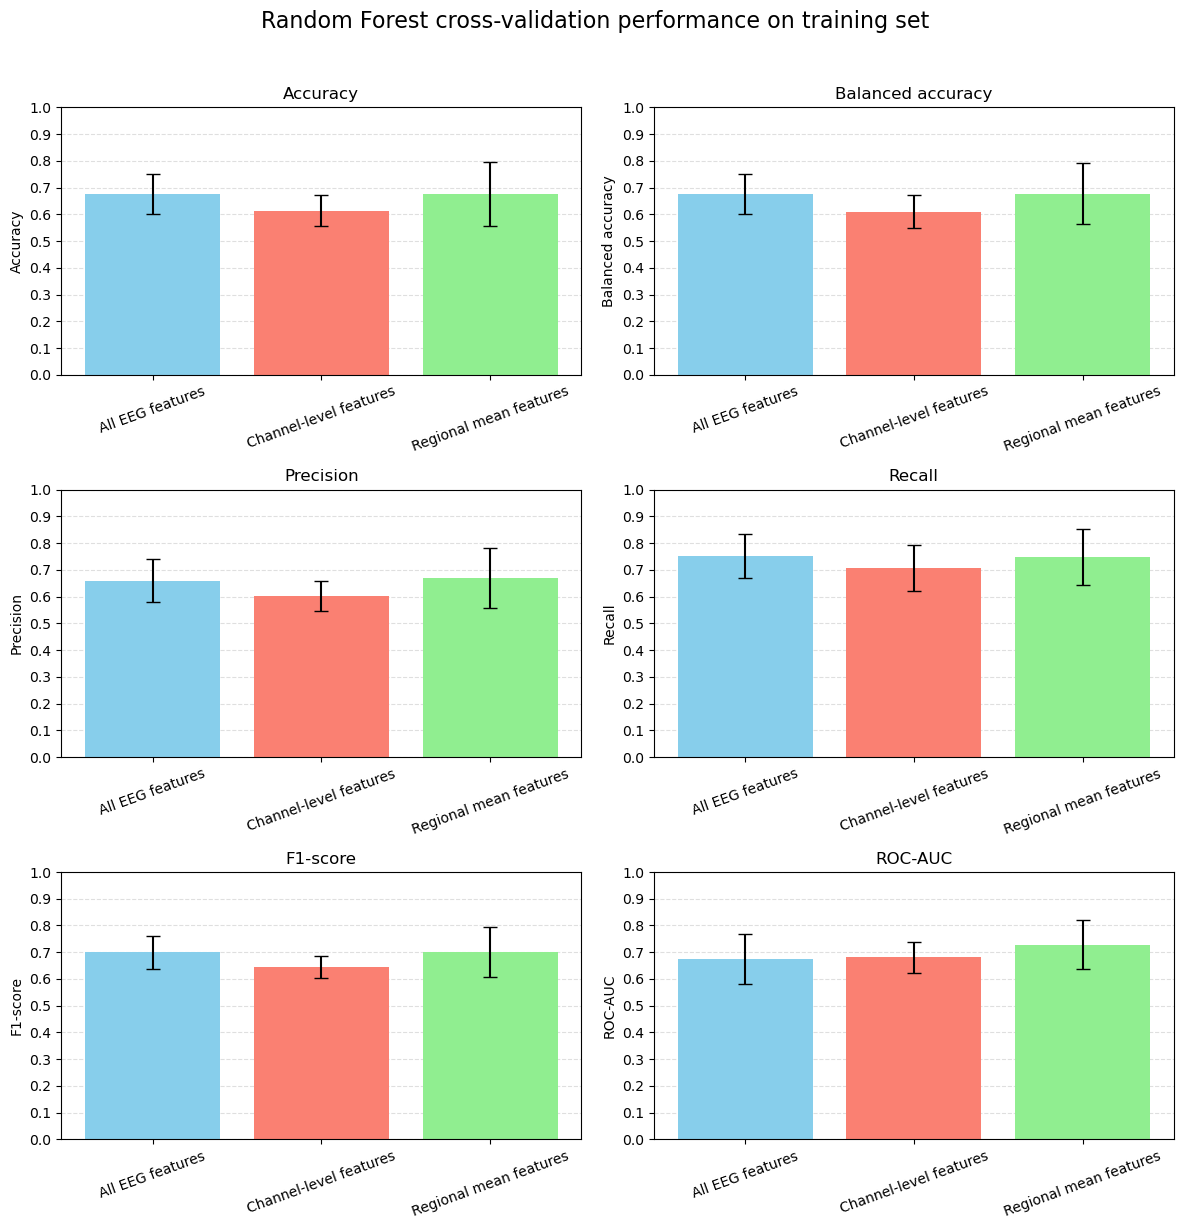

In [97]:
# metrics to plot for feature set comparison

metrics_to_plot = {
    "Accuracy": ("accuracy_mean", "accuracy_std"),
    "Balanced accuracy": ("balanced_accuracy_mean", "balanced_accuracy_std"),
    "Precision": ("precision_mean", "precision_std"),
    "Recall": ("recall_mean", "recall_std"),
    "F1-score": ("f1_mean", "f1_std"),
    "ROC-AUC": ("roc_auc_mean", "roc_auc_std"),
}

n_metrics = len(metrics_to_plot)
n_cols = 2
n_rows = int(np.ceil(n_metrics / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 4 * n_rows)
)

fig.suptitle(
    "Random Forest cross-validation performance on training set",
    fontsize=16,
    y=1.02
)

axes = np.array(axes).flatten()

for ax, (metric_name, (mean_col, std_col)) in zip(axes, metrics_to_plot.items()):

    ax.bar(
        rf_results_df["feature_set"],
        rf_results_df[mean_col],
        yerr=rf_results_df[std_col],
        capsize=5,
        color =["skyblue", "salmon", "lightgreen"]
    )

    ax.set_title(metric_name)
    ax.set_ylabel(metric_name)
    ax.set_ylim(0, 1)
    ax.set_yticks(np.arange(0, 1.01, 0.1))

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    ax.set_axisbelow(True)

    ax.tick_params(
        axis="x",
        rotation=20
    )

    ax.set_yticks(
        np.arange(0, 1.01, 0.1)
    )

for ax in axes[n_metrics:]:
    ax.axis("off")

plt.tight_layout()
save_figure("2a_rf_feature_set_comparison.png")
plt.show()

In [98]:
best_row = rf_results_df.sort_values(
    "balanced_accuracy_mean",
    ascending=False
).iloc[0]

best_feature_set_name = best_row["feature_set"]

print("Best feature set:")
print(best_feature_set_name)

if best_feature_set_name == "All EEG features":
    best_feature_cols = all_feature_cols

elif best_feature_set_name == "Channel-level features":
    best_feature_cols = channel_feature_cols

elif best_feature_set_name == "Regional mean features":
    best_feature_cols = regional_feature_cols

print("Number of selected features:", len(best_feature_cols))

Best feature set:
Regional mean features
Number of selected features: 25


### 5a. Best feature set



original_best_feature_set
Best parameters from RandomizedSearchCV:
{'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 1228}
Best randomized-search CV balanced accuracy:
0.6977777777777778
Table saved to: outputs\tabs\2a_rf_original_best_feature_set_randomized_search_results.csv
Table saved to: outputs\tabs\2a_rf_original_best_feature_set_randomized_search_best_params.csv

Local parameter grid:


{'n_estimators': [1028, 1228, 1428],
 'max_depth': [15, 20, 25, None],
 'min_samples_leaf': [2, 3, 4],
 'min_samples_split': [2, 4],
 'max_features': ['log2', 'sqrt', None]}

Best parameters after local GridSearchCV:
{'max_depth': 15, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 1028}
Best local grid-search CV balanced accuracy:
0.6977777777777778
Table saved to: outputs\tabs\2a_rf_original_best_feature_set_local_grid_search_results.csv
Table saved to: outputs\tabs\2a_rf_original_best_feature_set_local_grid_search_best_params.csv


,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,best_local_grid_cv_balanced_accuracy
0,15,log2,2,2,1028,0.697778


Table saved to: outputs\tabs\2a_rf_original_best_feature_set_test_metrics.csv


,feature_set,n_features,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,Regional mean features,25,0.76,0.75641,0.733333,0.846154,0.785714,0.730769


Figure saved to: outputs\figures\2a_rf_original_best_feature_set_roc_curve.png


<Figure size 600x600 with 0 Axes>

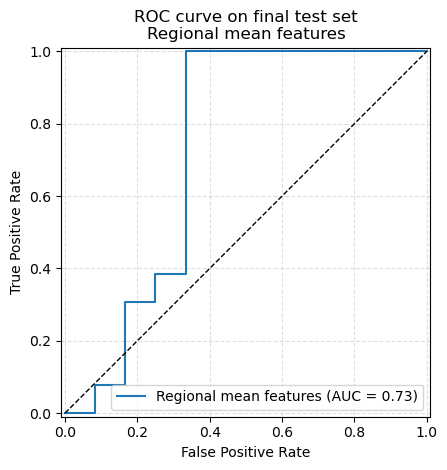

Table saved to: outputs\tabs\2a_rf_original_best_feature_set_confusion_matrix.csv
Figure saved to: outputs\figures\2a_rf_original_best_feature_set_confusion_matrix.png


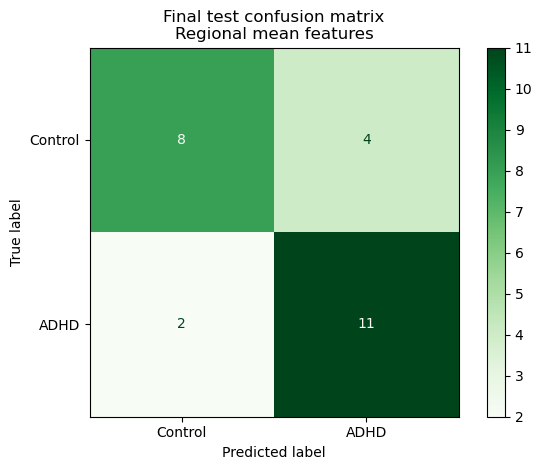

,Predicted Control,Predicted ADHD
True Control,8,4
True ADHD,2,11


Table saved to: outputs\tabs\2a_rf_original_best_feature_set_classification_report.csv


,precision,recall,f1-score,support
Control,0.800000,0.666667,0.727273,12.00
ADHD,0.733333,0.846154,0.785714,13.00
accuracy,0.760000,0.760000,0.760000,0.76
macro avg,0.766667,0.756410,0.756494,25.00
weighted avg,0.765333,0.760000,0.757662,25.00


In [99]:
# define X_train_best and X_test_best

X_train_best = train_df[best_feature_cols]
X_test_best = test_df[best_feature_cols]


# randomized search + local grid search

original_grid_search = randomized_then_local_grid_search(
    X_train=X_train_best,
    y_train=y_train,
    model_name="original_best_feature_set",
    n_iter=80,
    random_state=42
)


# final training on whole training set + final test evaluation

final_test_results_df, final_rf_model, y_test_pred, y_test_proba = evaluate_final_model_on_test_set(
    fitted_model=original_grid_search.best_estimator_,
    X_train=X_train_best,
    y_train=y_train,
    X_test=X_test_best,
    y_test=y_test,
    feature_set_name=best_feature_set_name,
    n_features=len(best_feature_cols),
    output_prefix="2a_rf_original_best_feature_set"
)

### 5b. Features importance

After training the final Random Forest model, feature importance values were extracted to identify which EEG features contributed most to the classification.

Random Forest feature importance is based on the concept of **mean decrease in impurity**. Each decision tree in the forest splits the data into nodes. At each split, the algorithm selects the feature and threshold that best separate the two classes.

In classification trees, node impurity is commonly measured using the Gini impurity:

$$
Gini = 1 - \sum_{k=1}^{K} p_k^2
$$

where $K$ is the number of classes and $p_k$ is the proportion of samples belonging to class $k$ in that node.

In this project, the two classes are ADHD and Control, so the Gini impurity can be written as:

$$
Gini = 1 - p_{ADHD}^{2} - p_{Control}^{2}
$$

A feature is considered important if it is used in splits that strongly reduce impurity. The importance of a feature is obtained by summing the impurity decreases from all splits where that feature is used, weighted by the number of samples reaching each node.

For a Random Forest, the feature importance is averaged across all trees in the forest and normalized so that the sum of all feature importances is equal to 1.

Therefore, features with higher importance values are those that contributed more to reducing classification impurity across the forest.




In [100]:
importance_df = pd.DataFrame({
    "feature": best_feature_cols,
    "importance": final_rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

#display(importance_df.head(20))

In [101]:
importance_df["pretty_feature"] = importance_df["feature"].apply(
    pretty_feature_name
)

save_table(
    importance_df,
    "2a_rf_best_feature_set_feature_importance.csv"
)

Table saved to: outputs\tabs\2a_rf_best_feature_set_feature_importance.csv


Figure saved to: outputs\figures\2a_rf_best_feature_set_feature_importance_top10.png


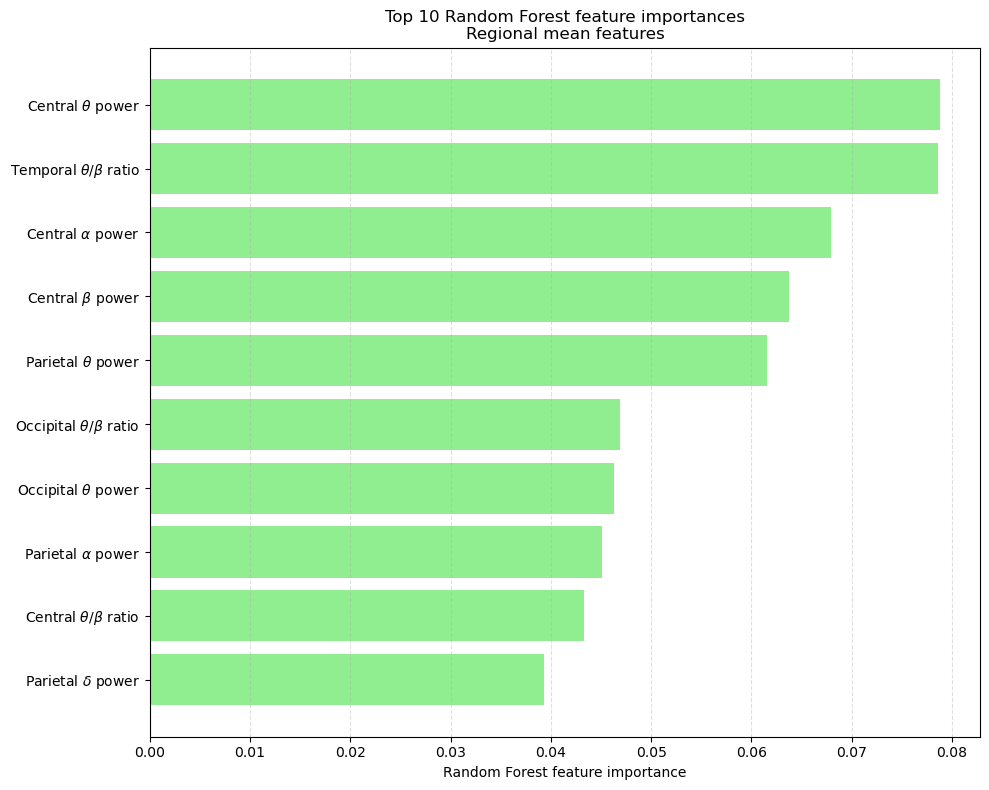

In [102]:
top_importance = importance_df.head(10).copy()

top_importance["pretty_feature"] = top_importance["feature"].apply(
    pretty_feature_name
)

plt.figure(figsize=(10, 8))

plt.xticks(np.arange(0, 0.1, 0.01))

plt.barh(
    top_importance["pretty_feature"],
    top_importance["importance"],
    color = 'lightgreen'
)

plt.xlabel("Random Forest feature importance")
plt.title(
    f"Top 10 Random Forest feature importances\n{best_feature_set_name}"
)

plt.gca().invert_yaxis()

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
save_figure("2a_rf_best_feature_set_feature_importance_top10.png")
plt.show()

Table saved to: outputs\tabs\2a_rf_top10_feature_importance_spearman_correlation.csv
Figure saved to: outputs\figures\2a_rf_top10_feature_importance_correlation_matrix.png


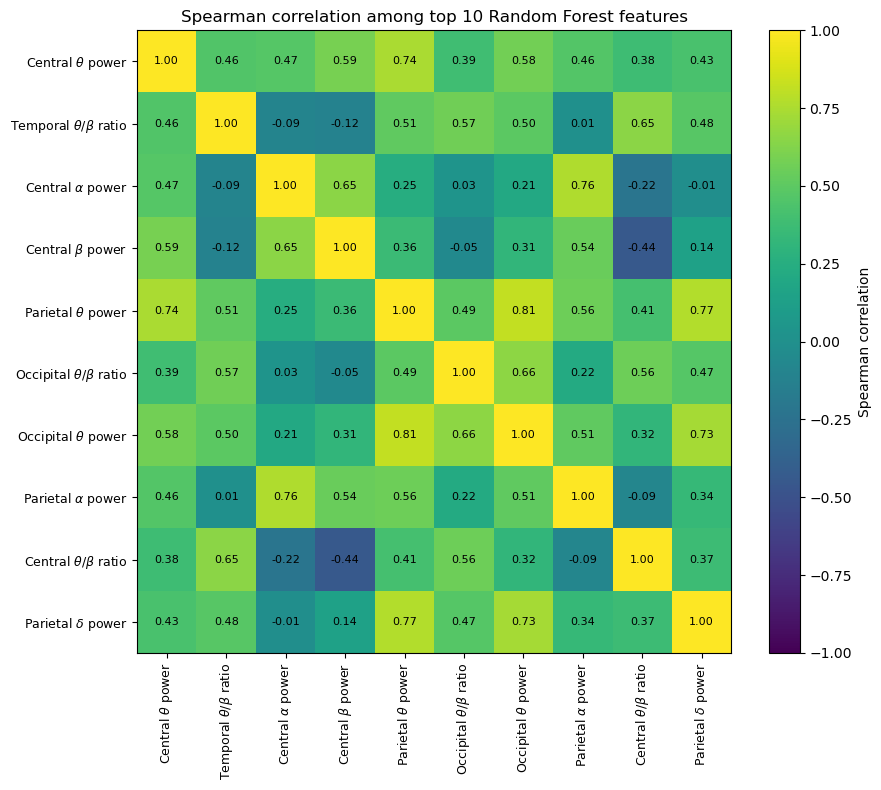

In [103]:
# Correlation matrix of the top 10 Random Forest features

top10_rf_features = importance_df.head(10)["feature"].tolist()

top10_rf_corr = train_df[top10_rf_features].corr(
    method="spearman"
)

top10_rf_corr_labels = [
    pretty_feature_name(feature)
    for feature in top10_rf_features
]

save_table(
    top10_rf_corr,
    "2a_rf_top10_feature_importance_spearman_correlation.csv",
    index=True
)

plt.figure(figsize=(9, 8))

plt.imshow(
    top10_rf_corr.values,
    vmin=-1,
    vmax=1,
    aspect="auto"
)

plt.colorbar(label="Spearman correlation")

plt.xticks(
    ticks=np.arange(len(top10_rf_corr_labels)),
    labels=top10_rf_corr_labels,
    rotation=90,
    fontsize=9
)

plt.yticks(
    ticks=np.arange(len(top10_rf_corr_labels)),
    labels=top10_rf_corr_labels,
    fontsize=9
)

for i in range(top10_rf_corr.shape[0]):
    for j in range(top10_rf_corr.shape[1]):

        value = top10_rf_corr.iloc[i, j]

        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Spearman correlation among top 10 Random Forest features")

plt.tight_layout()
save_figure("2a_rf_top10_feature_importance_correlation_matrix.png")
plt.show()

### 6. Correlation-based reduction of the most important features

Since some of the most important Random Forest features showed moderate-to-high Spearman correlations, a reduced feature set was created to limit redundancy.

Starting from the features ranked by Random Forest importance, features were selected iteratively. At each step, a candidate feature was retained only if its absolute Spearman correlation with all previously selected features was lower than a predefined threshold.

This procedure keeps the most important features while removing highly correlated variables that may provide overlapping information.

In [104]:
ranked_rf_features = importance_df["feature"].tolist()

In [ ]:
thresholds = [0.70, 0.75, 0.80, 0.85]

threshold_results = []

for threshold in thresholds:

    selected_features, removed_df = select_uncorrelated_features_by_importance(
        ranked_features=ranked_rf_features,
        data=train_df,
        corr_threshold=threshold,
        method="spearman"
    )

    result = evaluate_feature_set(
        f"Reduced features | threshold={threshold}",
        selected_features
    )

    result["corr_threshold"] = threshold
    result["selected_features"] = selected_features
    result["removed_features"] = removed_df["removed_feature"].tolist() if len(removed_df) > 0 else []

    threshold_results.append(result)

threshold_results_df = pd.DataFrame(threshold_results)

save_table(
    threshold_results_df,
    "2a_rf_correlation_threshold_comparison.csv"
)

display(threshold_results_df[
    [
        "corr_threshold",
        "n_features",
        "balanced_accuracy_mean",
        "balanced_accuracy_std",
        "f1_mean",
        "f1_std",
        "roc_auc_mean",
        "roc_auc_std"
    ]
])

Table saved to: outputs\tabs\2a_rf_correlation_threshold_comparison.csv


,corr_threshold,n_features,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,0.60,8,0.708889,0.105210,0.736597,0.090232,0.710667,0.139667
1,0.70,12,0.646667,0.105853,0.663636,0.100686,0.736889,0.173109
2,0.75,17,0.667778,0.114201,0.692935,0.096635,0.723111,0.089239
3,0.80,19,0.718889,0.081771,0.749683,0.080294,0.752000,0.069005
4,0.85,24,0.657778,0.127976,0.673859,0.134588,0.701333,0.134870
5,0.90,25,0.687778,0.100210,0.702670,0.094025,0.709333,0.094191


In [106]:
best_threshold_row = threshold_results_df.sort_values(
    "balanced_accuracy_mean",
    ascending=False
).iloc[0]

best_corr_threshold = best_threshold_row["corr_threshold"]

print("Best correlation threshold:", best_corr_threshold)
print("Best CV balanced accuracy:", best_threshold_row["balanced_accuracy_mean"])
print("Number of selected features:", best_threshold_row["n_features"])

Best correlation threshold: 0.8
Best CV balanced accuracy: 0.718888888888889
Number of selected features: 19


In [ ]:
### final model with correlation-reduced features

# Recompute the reduced feature set using the best correlation threshold
# selected only on the training/validation set

final_reduced_feature_cols, final_removed_features_df = select_uncorrelated_features_by_importance(
    ranked_features=ranked_rf_features,
    data=train_df,
    corr_threshold=best_corr_threshold,
    method="spearman"
)

print("Best correlation threshold:", best_corr_threshold)
print("Number of final reduced features:", len(final_reduced_feature_cols))

print("\nFinal selected features:")
for feature in final_reduced_feature_cols:
    print(feature)


Best correlation threshold: 0.8
Number of final reduced features: 19

Final selected features:
- Central ${\theta}$ power
- Temporal ${\theta}/{\beta}$ ratio
- Central ${\alpha}$ power
- Central ${\beta}$ power
- Parietal ${\theta}$ power
- Occipital ${\theta}/{\beta}$ ratio
- Parietal ${\alpha}$ power
- Central ${\theta}/{\beta}$ ratio
- Parietal ${\delta}$ power
- Frontal ${\alpha}$ power
- Frontal ${\theta}$ power
- Occipital ${\beta}$ power
- frontal_delta_power_mean
- Parietal ${\beta}$ power
- Temporal ${\delta}$ power
- occipital_alpha_power_mean
- Temporal ${\beta}$ power
- Frontal ${\beta}$ power
- Frontal ${\theta}/{\beta}$ ratio

Removed features:


,removed_feature,max_correlation_with_selected,most_correlated_selected_feature
0,occipital_theta_power_mean,0.813049,parietal_theta_power_mean
1,occipital_delta_power_mean,0.894778,parietal_delta_power_mean
2,temporal_theta_power_mean,0.803106,central_theta_power_mean
3,central_delta_power_mean,0.842878,parietal_delta_power_mean
4,parietal_theta_beta_ratio,0.819886,central_theta_beta_ratio
5,temporal_alpha_power_mean,0.809794,frontal_alpha_power_mean


Table saved to: outputs\tabs\2a_rf_final_reduced_selected_features.csv
Table saved to: outputs\tabs\2a_rf_final_reduced_removed_features.csv


In [108]:
X_train_reduced = train_df[final_reduced_feature_cols]
X_test_reduced = test_df[final_reduced_feature_cols]

print("X_train_reduced shape:", X_train_reduced.shape)
print("X_test_reduced shape:", X_test_reduced.shape)

X_train_reduced shape: (96, 19)
X_test_reduced shape: (25, 19)



correlation_reduced_feature_set
Best parameters from RandomizedSearchCV:
{'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 13, 'n_estimators': 1154}
Best randomized-search CV balanced accuracy:
0.7288888888888889
Table saved to: outputs\tabs\2a_rf_correlation_reduced_feature_set_randomized_search_results.csv
Table saved to: outputs\tabs\2a_rf_correlation_reduced_feature_set_randomized_search_best_params.csv

Local parameter grid:


{'n_estimators': [954, 1154, 1354],
 'max_depth': [1, 5, 10, None],
 'min_samples_leaf': [1, 2],
 'min_samples_split': [11, 13, 15],
 'max_features': ['sqrt', 'log2', None]}

Best parameters after local GridSearchCV:
{'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 13, 'n_estimators': 954}
Best local grid-search CV balanced accuracy:
0.7288888888888889
Table saved to: outputs\tabs\2a_rf_correlation_reduced_feature_set_local_grid_search_results.csv
Table saved to: outputs\tabs\2a_rf_correlation_reduced_feature_set_local_grid_search_best_params.csv


,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,best_local_grid_cv_balanced_accuracy
0,5,sqrt,1,13,954,0.728889


Table saved to: outputs\tabs\2a_rf_correlation_reduced_feature_set_test_metrics.csv


,feature_set,n_features,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,correlation_threshold
0,Correlation-reduced RF features,19,0.72,0.717949,0.714286,0.769231,0.740741,0.75641,0.8


Figure saved to: outputs\figures\2a_rf_correlation_reduced_feature_set_roc_curve.png


<Figure size 600x600 with 0 Axes>

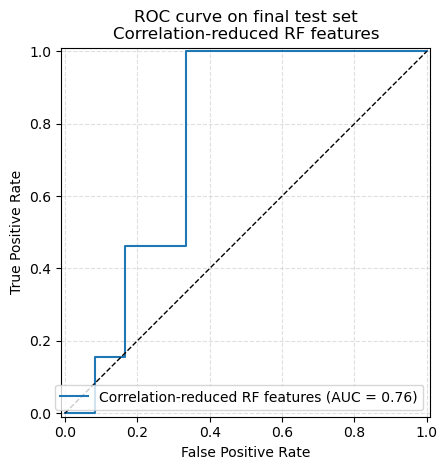

Table saved to: outputs\tabs\2a_rf_correlation_reduced_feature_set_confusion_matrix.csv
Figure saved to: outputs\figures\2a_rf_correlation_reduced_feature_set_confusion_matrix.png


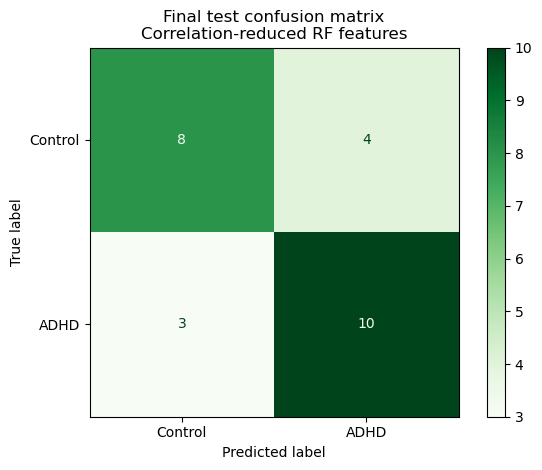

,Predicted Control,Predicted ADHD
True Control,8,4
True ADHD,3,10


Table saved to: outputs\tabs\2a_rf_correlation_reduced_feature_set_classification_report.csv


,precision,recall,f1-score,support
Control,0.727273,0.666667,0.695652,12.00
ADHD,0.714286,0.769231,0.740741,13.00
accuracy,0.720000,0.720000,0.720000,0.72
macro avg,0.720779,0.717949,0.718196,25.00
weighted avg,0.720519,0.720000,0.719098,25.00


In [ ]:

# RandomizedSearchCV + local GridSearchCV

reduced_grid_search = randomized_then_local_grid_search(
    X_train=X_train_reduced,
    y_train=y_train,
    model_name="correlation_reduced_feature_set",
    n_iter=80,
    random_state=42
)

final_reduced_test_results_df, final_reduced_rf_model, y_test_reduced_pred, y_test_reduced_proba = evaluate_final_model_on_test_set(
    fitted_model=reduced_grid_search.best_estimator_,
    X_train=X_train_reduced,
    y_train=y_train,
    X_test=X_test_reduced,
    y_test=y_test,
    feature_set_name="Correlation-reduced RF features",
    n_features=len(final_reduced_feature_cols),
    output_prefix="2a_rf_correlation_reduced_feature_set",
    extra_info={
        "correlation_threshold": best_corr_threshold
    }
)

### 7. Classification using only theta/beta ratio features

To directly test whether the theta/beta ratio alone is sufficient to classify ADHD and Control subjects, an additional classification analysis was performed using only theta/beta ratio features.

This analysis was included because the theta/beta ratio has historically been proposed as a possible EEG marker of ADHD, but previous literature has questioned whether it is sufficient as a standalone diagnostic feature.

Therefore, model performance obtained using only theta/beta ratio features was compared with the performance obtained using the complete best feature set and the correlation-reduced feature set.

In [121]:
# All theta/beta ratio features
theta_beta_cols = [
    col for col in all_feature_cols
    if "theta_beta_ratio" in col
]

# Regional theta/beta ratio features
regional_theta_beta_cols = [
    col for col in theta_beta_cols
    if (
        col.startswith("frontal_")
        or col.startswith("central_")
        or col.startswith("temporal_")
        or col.startswith("parietal_")
        or col.startswith("occipital_")
    )
]

# Channel-level theta/beta ratio features
channel_theta_beta_cols = [
    col for col in theta_beta_cols
    if col not in regional_theta_beta_cols
]

print("\nRegional theta/beta ratio features:", len(regional_theta_beta_cols))
for col in regional_theta_beta_cols:
    print("-", col)

print("\nChannel-level theta/beta ratio features:", len(channel_theta_beta_cols))
for col in channel_theta_beta_cols:
    print("-", col)


Regional theta/beta ratio features: 5
- frontal_theta_beta_ratio
- central_theta_beta_ratio
- parietal_theta_beta_ratio
- temporal_theta_beta_ratio
- occipital_theta_beta_ratio

Channel-level theta/beta ratio features: 19
- Fp1_theta_beta_ratio
- Fp2_theta_beta_ratio
- F3_theta_beta_ratio
- F4_theta_beta_ratio
- C3_theta_beta_ratio
- C4_theta_beta_ratio
- P3_theta_beta_ratio
- P4_theta_beta_ratio
- O1_theta_beta_ratio
- O2_theta_beta_ratio
- F7_theta_beta_ratio
- F8_theta_beta_ratio
- T7_theta_beta_ratio
- T8_theta_beta_ratio
- P7_theta_beta_ratio
- P8_theta_beta_ratio
- Fz_theta_beta_ratio
- Cz_theta_beta_ratio
- Pz_theta_beta_ratio


In [122]:
# cross-validation comparison of theta/beta ratio feature sets

theta_beta_cv_results = []

theta_beta_cv_results.append(
    evaluate_feature_set(
        "Regional theta/beta ratio features",
        regional_theta_beta_cols
    )
)

theta_beta_cv_results.append(
    evaluate_feature_set(
        "Channel-level theta/beta ratio features",
        channel_theta_beta_cols
    )
)

theta_beta_cv_results.append(
    evaluate_feature_set(
        "All theta/beta ratio features",
        theta_beta_cols
    )
)

theta_beta_cv_results_df = pd.DataFrame(theta_beta_cv_results)

save_table(
    theta_beta_cv_results_df,
    "2a_rf_theta_beta_ratio_feature_sets_cv_results.csv"
)

display(theta_beta_cv_results_df)

Table saved to: outputs\tabs\2a_rf_theta_beta_ratio_feature_sets_cv_results.csv


,feature_set,n_features,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std
0,Regional theta/beta ratio features,5,0.541579,0.102008,0.541111,0.103315,0.572623,0.109542,0.681333,0.151702,0.550000,0.095452,0.644444,0.202332
1,Channel-level theta/beta ratio features,19,0.574737,0.111718,0.575556,0.111422,0.609051,0.069192,0.614222,0.123085,0.585831,0.111437,0.648889,0.069424
2,All theta/beta ratio features,24,0.553158,0.117221,0.554444,0.116926,0.596469,0.076355,0.618222,0.137723,0.567576,0.118847,0.648889,0.093914


In [123]:
best_tbr_row = theta_beta_cv_results_df.sort_values(
    "balanced_accuracy_mean",
    ascending=False
).iloc[0]

best_tbr_feature_set_name = best_tbr_row["feature_set"]

if best_tbr_feature_set_name == "Regional theta/beta ratio features":
    best_tbr_feature_cols = regional_theta_beta_cols

elif best_tbr_feature_set_name == "Channel-level theta/beta ratio features":
    best_tbr_feature_cols = channel_theta_beta_cols

elif best_tbr_feature_set_name == "All theta/beta ratio features":
    best_tbr_feature_cols = theta_beta_cols

print("Best theta/beta ratio feature set:")
print(best_tbr_feature_set_name)

print("Number of selected theta/beta ratio features:", len(best_tbr_feature_cols))

Best theta/beta ratio feature set:
Channel-level theta/beta ratio features
Number of selected theta/beta ratio features: 19


In [124]:
# hyperparameter tuning on the best theta/beta ratio feature set

X_train_tbr = train_df[best_tbr_feature_cols]
X_test_tbr = test_df[best_tbr_feature_cols]

tbr_grid_search = randomized_then_local_grid_search(
    X_train=X_train_tbr,
    y_train=y_train,
    model_name="theta_beta_ratio_feature_set",
    n_iter=80,
    random_state=42
)


theta_beta_ratio_feature_set
Best parameters from RandomizedSearchCV:
{'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 9, 'n_estimators': 330}
Best randomized-search CV balanced accuracy:
0.6188888888888888
Table saved to: outputs\tabs\2a_rf_theta_beta_ratio_feature_set_randomized_search_results.csv
Table saved to: outputs\tabs\2a_rf_theta_beta_ratio_feature_set_randomized_search_best_params.csv

Local parameter grid:


{'n_estimators': [130, 330, 530],
 'max_depth': [1, 5, 10, None],
 'min_samples_leaf': [3, 4, 5],
 'min_samples_split': [7, 9, 11],
 'max_features': ['sqrt', 'log2', None]}

c:\Users\noemi\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best parameters after local GridSearchCV:
{'max_depth': 1, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 7, 'n_estimators': 330}
Best local grid-search CV balanced accuracy:
0.6444444444444445
Table saved to: outputs\tabs\2a_rf_theta_beta_ratio_feature_set_local_grid_search_results.csv
Table saved to: outputs\tabs\2a_rf_theta_beta_ratio_feature_set_local_grid_search_best_params.csv


,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,best_local_grid_cv_balanced_accuracy
0,1,sqrt,3,7,330,0.644444


Table saved to: outputs\tabs\2a_rf_theta_beta_ratio_feature_set_test_metrics.csv


,feature_set,n_features,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,Channel-level theta/beta ratio features,19,0.76,0.753205,0.705882,0.923077,0.8,0.705128


Figure saved to: outputs\figures\2a_rf_theta_beta_ratio_feature_set_roc_curve.png


<Figure size 600x600 with 0 Axes>

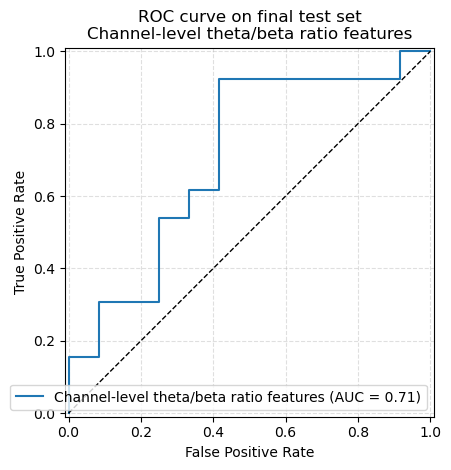

Table saved to: outputs\tabs\2a_rf_theta_beta_ratio_feature_set_confusion_matrix.csv
Figure saved to: outputs\figures\2a_rf_theta_beta_ratio_feature_set_confusion_matrix.png


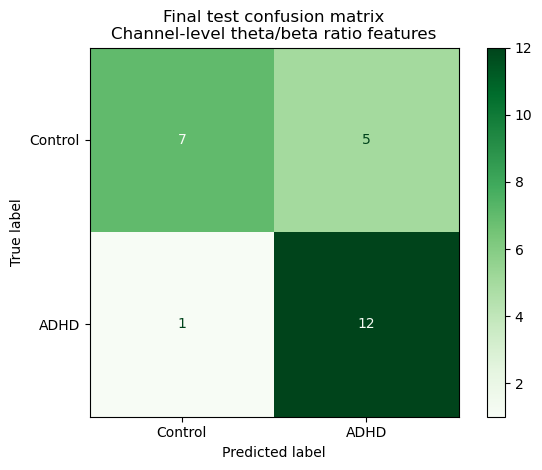

,Predicted Control,Predicted ADHD
True Control,7,5
True ADHD,1,12


Table saved to: outputs\tabs\2a_rf_theta_beta_ratio_feature_set_classification_report.csv


,precision,recall,f1-score,support
Control,0.875000,0.583333,0.700,12.00
ADHD,0.705882,0.923077,0.800,13.00
accuracy,0.760000,0.760000,0.760,0.76
macro avg,0.790441,0.753205,0.750,25.00
weighted avg,0.787059,0.760000,0.752,25.00


In [125]:
# Final test evaluation of the theta/beta ratio model

tbr_test_results_df, tbr_rf_model, y_test_tbr_pred, y_test_tbr_proba = evaluate_final_model_on_test_set(
    fitted_model=tbr_grid_search.best_estimator_,
    X_train=X_train_tbr,
    y_train=y_train,
    X_test=X_test_tbr,
    y_test=y_test,
    feature_set_name=best_tbr_feature_set_name,
    n_features=len(best_tbr_feature_cols),
    output_prefix="2a_rf_theta_beta_ratio_feature_set"
)

In [126]:
# final comparison

final_model_comparison_with_tbr_df = pd.concat(
    [
        final_test_results_df.assign(model="Original best feature set"),
        final_reduced_test_results_df.assign(model="Correlation-reduced feature set"),
        tbr_test_results_df.assign(model="Theta/beta ratio feature set")
    ],
    ignore_index=True
)

save_table(
    final_model_comparison_with_tbr_df,
    "2a_rf_final_test_metrics_with_theta_beta_ratio.csv"
)

display(final_model_comparison_with_tbr_df[
    [
        "model",
        "feature_set",
        "n_features",
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ]
])

Table saved to: outputs\tabs\2a_rf_final_test_metrics_with_theta_beta_ratio.csv


,model,feature_set,n_features,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,Original best feature set,Regional mean features,25,0.76,0.756410,0.733333,0.846154,0.785714,0.730769
1,Correlation-reduced feature set,Correlation-reduced RF features,19,0.72,0.717949,0.714286,0.769231,0.740741,0.756410
2,Theta/beta ratio feature set,Channel-level theta/beta ratio features,19,0.76,0.753205,0.705882,0.923077,0.800000,0.705128
